In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 45.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

In [9]:
# Sample molecules
data = {
    "Name": ["Aspirin","Caffeine","Ibuprofen","Paracetamol"],
    "SMILES": [
        "CC(=O)OC1=CC=CC=C1C(=O)O",
        "CN1C=NC2=C1C(=O)N(C)C(=O)N2C",
        "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
        "CC(=O)NC1=CC=C(O)C=C1"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [10]:
# Convert SMILES to molecules
df["Mol"] = df["SMILES"].apply(Chem.MolFromSmiles)

# Calculate descriptors
df["MW"] = df["Mol"].apply(Descriptors.MolWt)
df["logP"] = df["Mol"].apply(Descriptors.MolLogP)
df["TPSA"] = df["Mol"].apply(Descriptors.TPSA)

# Show dataset
print(df)

          Name                         SMILES  \
0      Aspirin       CC(=O)OC1=CC=CC=C1C(=O)O   
1     Caffeine   CN1C=NC2=C1C(=O)N(C)C(=O)N2C   
2    Ibuprofen  CC(C)CC1=CC=C(C=C1)C(C)C(=O)O   
3  Paracetamol          CC(=O)NC1=CC=C(O)C=C1   

                                                Mol       MW    logP   TPSA  
0  <rdkit.Chem.rdchem.Mol object at 0x7dd7422bb3e0>  180.159  1.3101  63.60  
1  <rdkit.Chem.rdchem.Mol object at 0x7dd741a21f50>  194.194 -1.0293  61.82  
2  <rdkit.Chem.rdchem.Mol object at 0x7dd741a22340>  206.285  3.0732  37.30  
3  <rdkit.Chem.rdchem.Mol object at 0x7dd741a22b20>  151.165  1.3506  49.33  


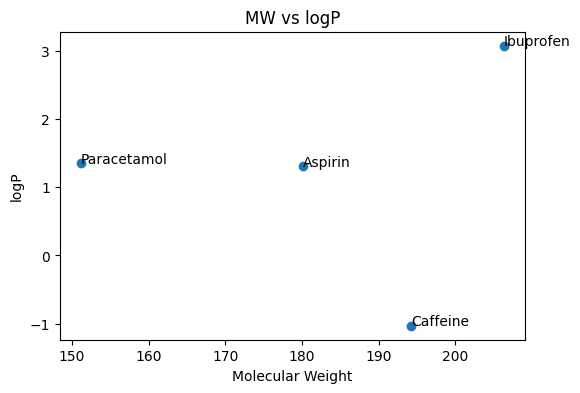

In [12]:
# Create scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df["MW"],df["logP"])

# Add labels
for i, name in enumerate(df["Name"]):
    plt.text(df["MW"][i],df["logP"][i],name)

# Axis labels
plt.xlabel("Molecular Weight")
plt.ylabel("logP")

# Title
plt.title("MW vs logP")

# Show plot
plt.show()

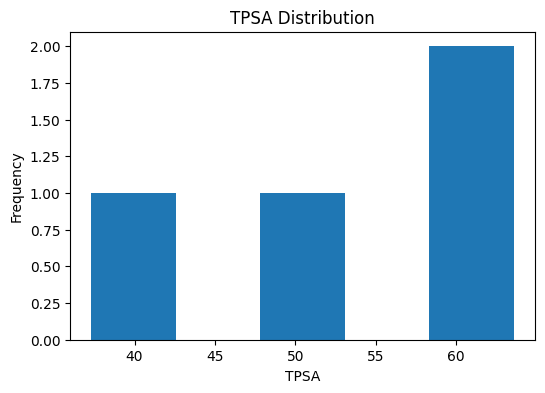

In [13]:
# Histogram of TPSA
plt.figure(figsize=(6,4))
plt.hist(df["TPSA"],bins=5)
plt.xlabel("TPSA")
plt.ylabel("Frequency")
plt.title("TPSA Distribution")
plt.show()